STEP 1: DATA UNDERSTANDING
Shape: (8955, 11)

Columns:
['country', 'year', 'iso_code', 'population', 'gdp', 'gdp_per_capita', 'poverty_rate', 'gini_index', 'income_top1', 'income_top10', 'income_bottom50'] 

Data types:
country             object
year                 int64
iso_code            object
population           int64
gdp                float64
gdp_per_capita     float64
poverty_rate       float64
gini_index         float64
income_top1        float64
income_top10       float64
income_bottom50    float64
dtype: object 

Missing values (top 30):
poverty_rate       6748
gini_index         6748
gdp                1920
gdp_per_capita     1920
income_top1         675
income_top10        675
income_bottom50     675
country               0
year                  0
iso_code              0
population            0
dtype: int64 

Detected key columns:
Country column: country
Year column: year
Gini column: gini_index
Poverty column: poverty_rate
GDP/Income column: gdp
Top share column (optio

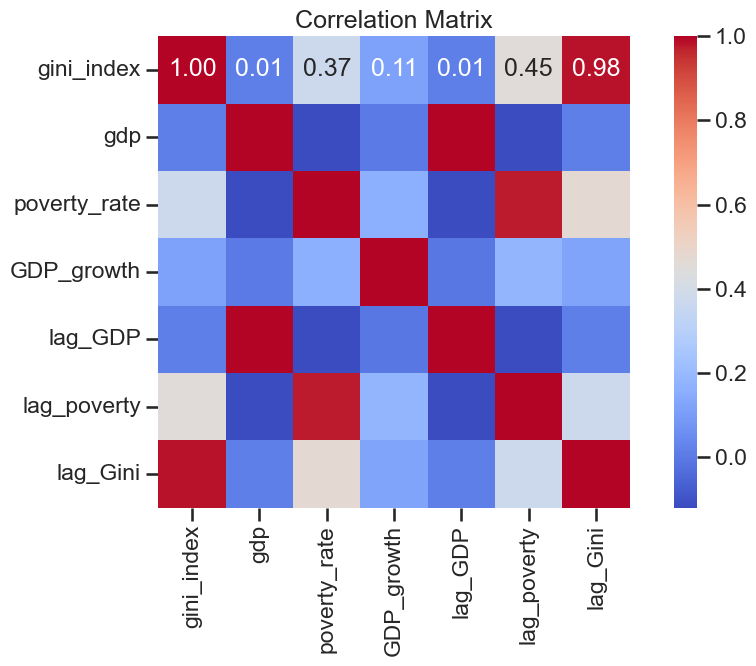

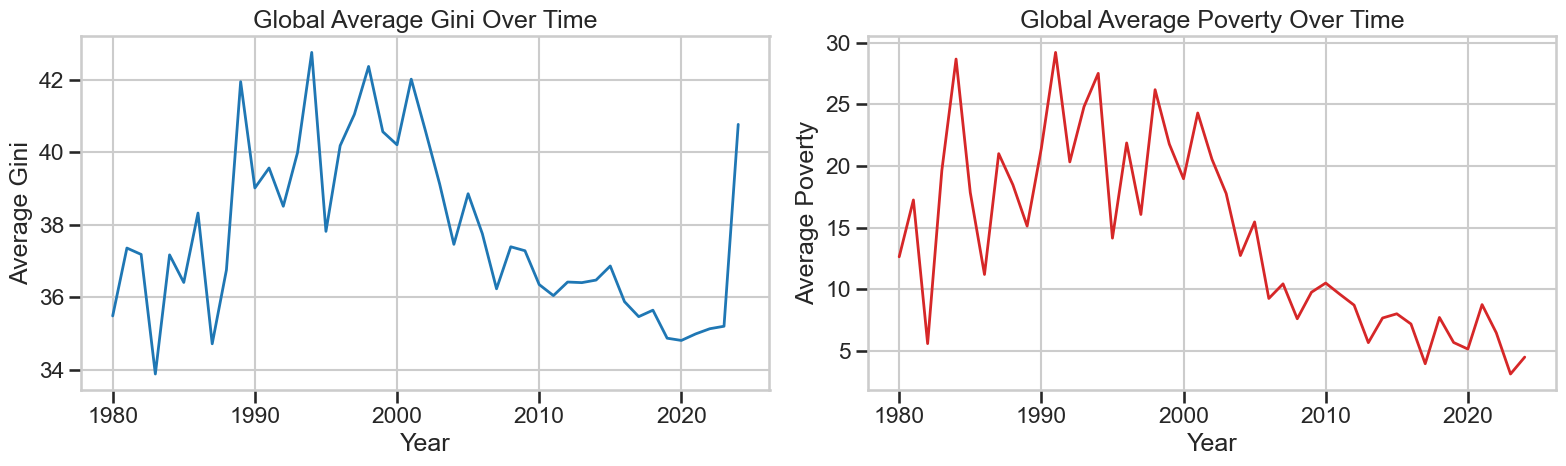

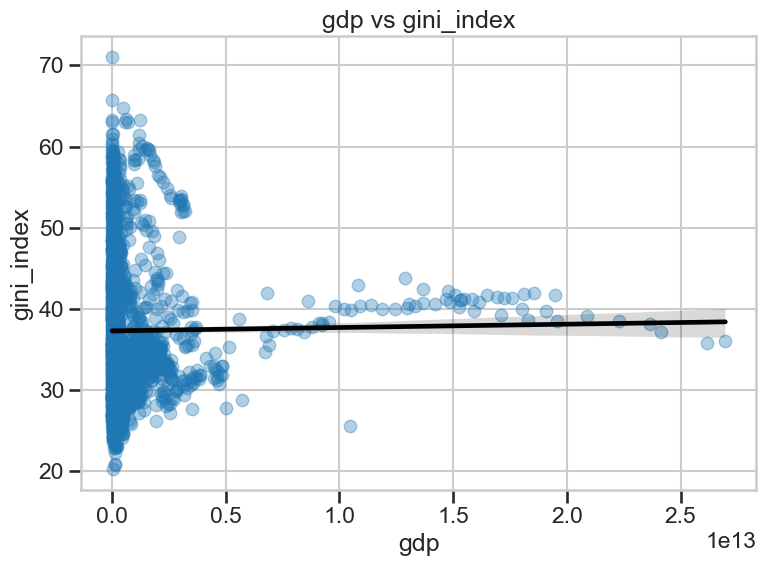

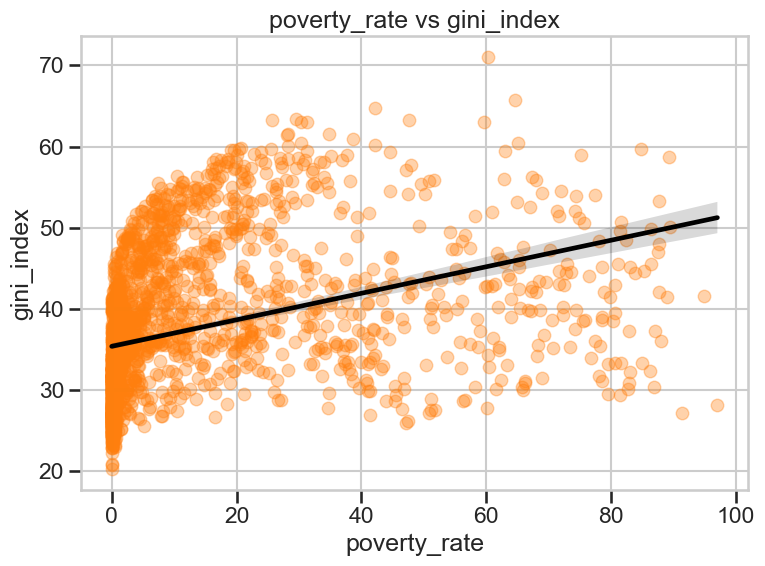

Plot interpretation guide (replace with values from your run):
- Global Gini trend: evaluate whether average inequality rises/falls across decades.
- Global poverty trend: assess long-run poverty reduction speed and breaks.
- GDP vs Gini scatter: weak/negative/positive slope indicates growth-inequality association.
- Poverty vs Gini scatter: positive slope often suggests deeper poverty aligns with higher inequality.

STEP 5: COUNTRY CASE STUDIES


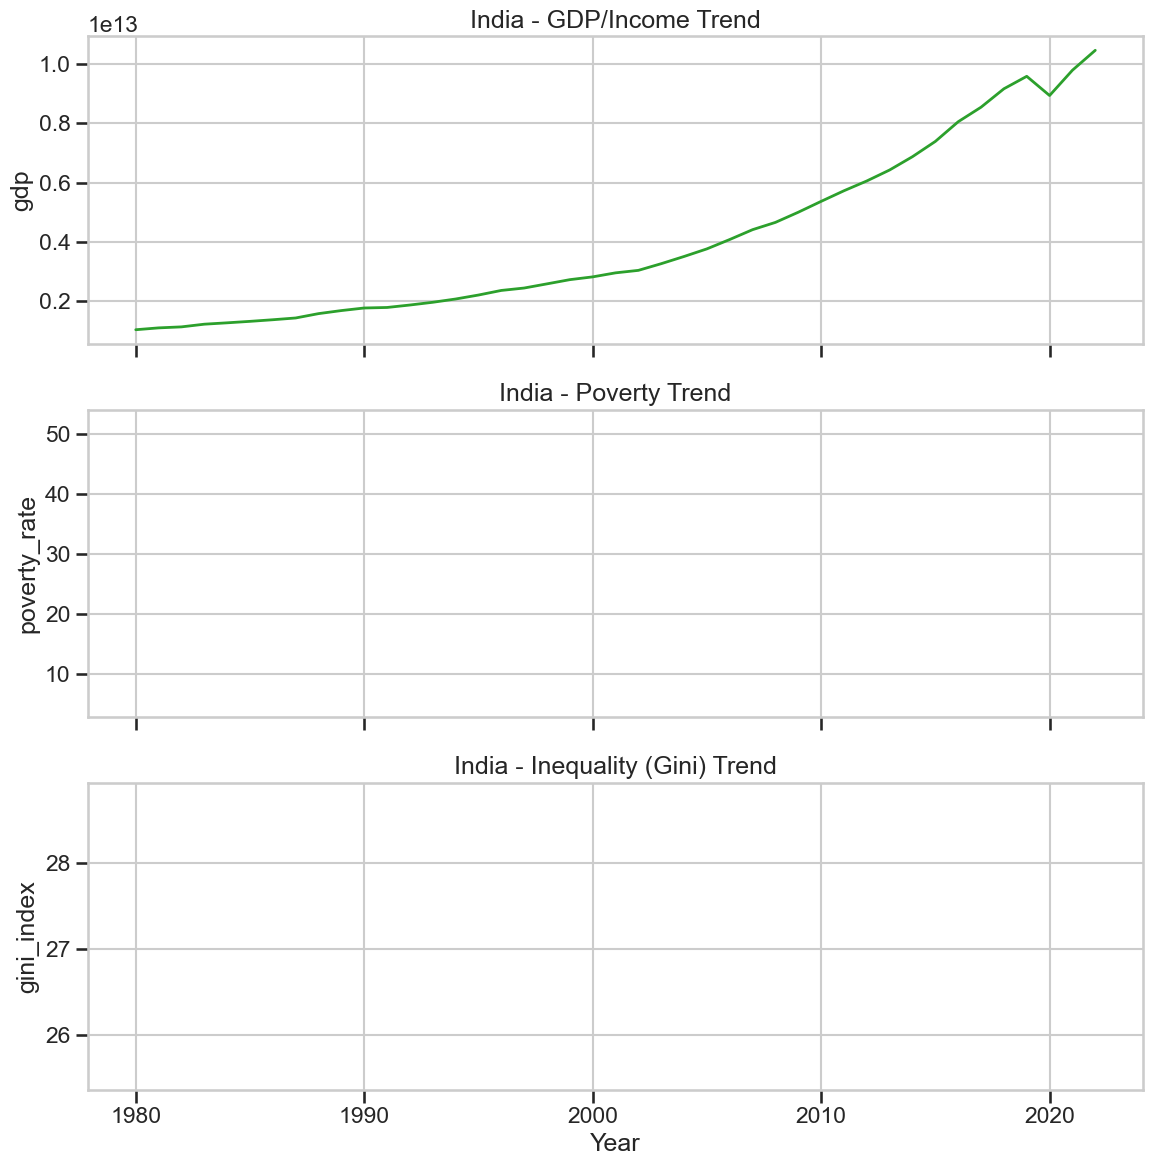

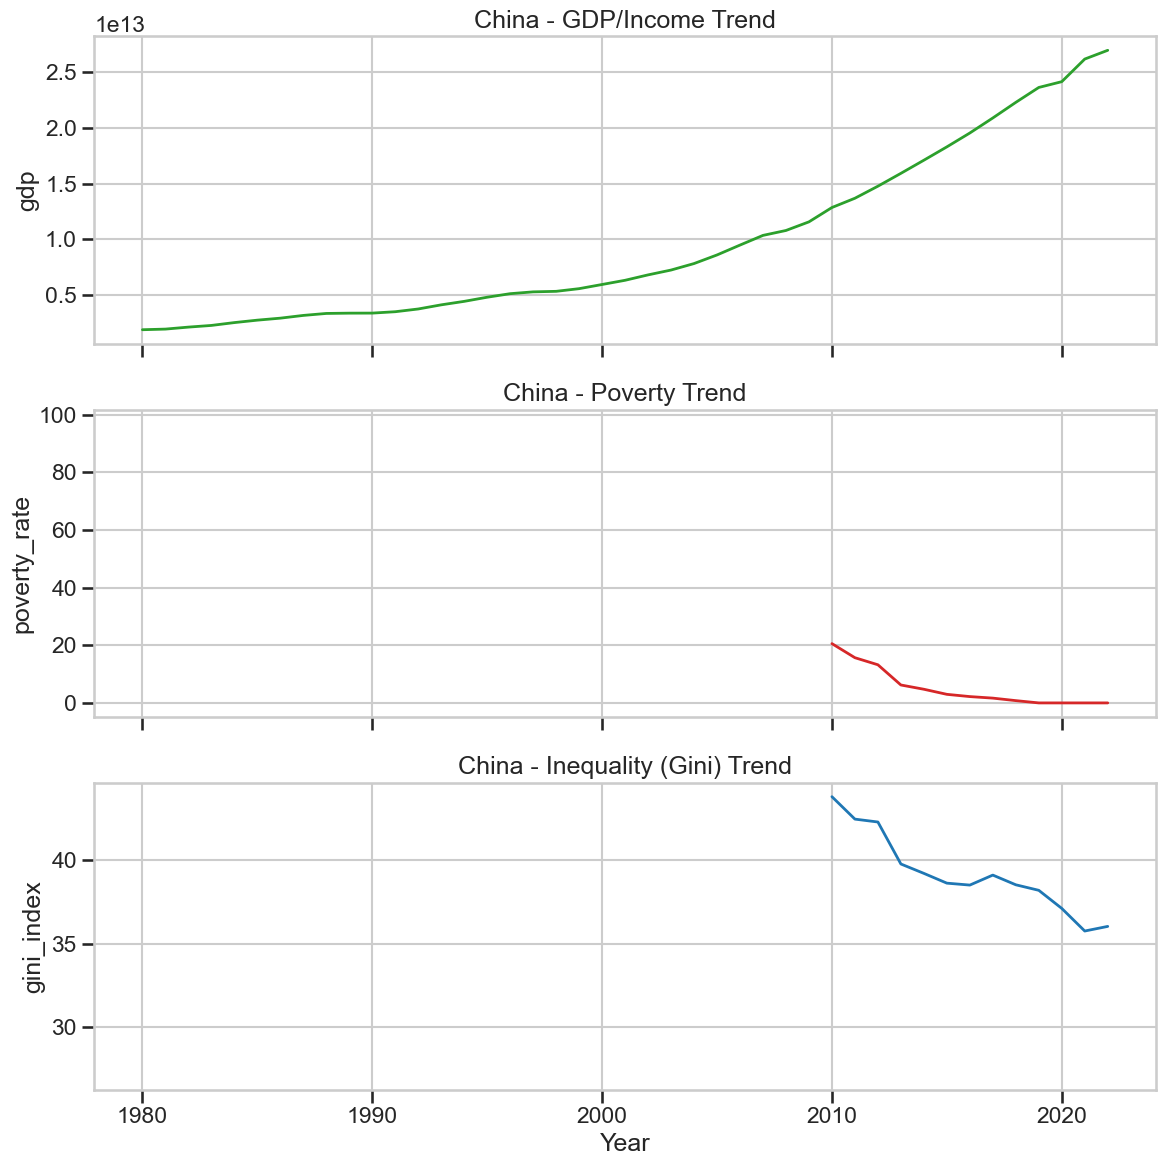

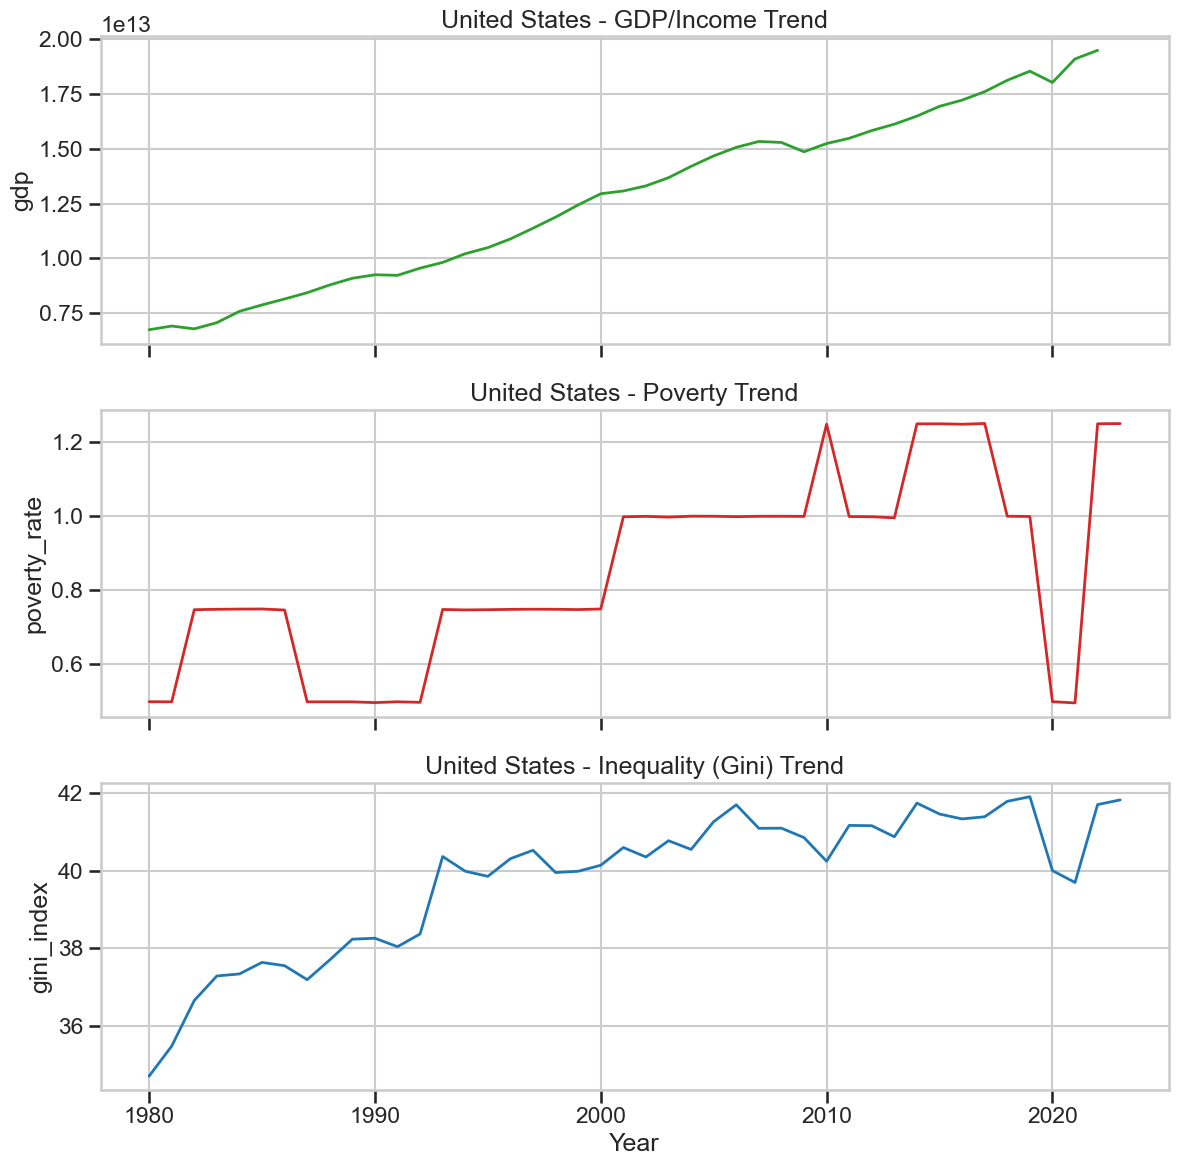

Country insight template:
- India: Check if rapid growth periods coincide with poverty decline and Gini changes.
- China: Evaluate growth-poverty transformation and inequality transition dynamics.
- United States: Compare mature economy pattern where growth may not strongly reduce Gini.

STEP 6: ECONOMETRIC MODELING
Model sample size: 2092
Countries: 150 | Years: 43

Model 1: Pooled OLS Results
                            OLS Regression Results                            
Dep. Variable:        Q("gini_index")   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     130.9
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           2.73e-54
Time:                        00:03:55   Log-Likelihood:                -7367.1
No. Observations:                2092   AIC:                         1.474e+04
Df Residuals:                    2089   BIC:     

In [ ]:
# ============================================================
# Project Title:
# Does Economic Growth Reduce Inequality?
# A Global Panel Data Analysis (1980–2024)
# ============================================================

# ----------------------------
# 0) Imports & Configuration
# ----------------------------
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Optional FE package (preferred for panel FE models)
try:
    from linearmodels.panel import PanelOLS
    LINEARMODELS_AVAILABLE = True
except Exception:
    LINEARMODELS_AVAILABLE = False

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")


# ----------------------------
# 1) DATA UNDERSTANDING
# ----------------------------
# Use exactly the path you provided:
DATA_PATH = r"D:\GITHUB\New folder\global-economic-inequality-and-poverty-1980-2024\disuguaglianza-economica-globale-e-povert-1980-2024.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n"
        "Please verify the path and filename."
    )

# Load dataset
df_raw = pd.read_csv(DATA_PATH)

print("="*70)
print("STEP 1: DATA UNDERSTANDING")
print("="*70)
print(f"Shape: {df_raw.shape}\n")
print("Columns:")
print(df_raw.columns.tolist(), "\n")
print("Data types:")
print(df_raw.dtypes, "\n")
print("Missing values (top 30):")
print(df_raw.isna().sum().sort_values(ascending=False).head(30), "\n")

# Keep a working copy
df = df_raw.copy()

# ------------------------------------------------------------
# Helper function to auto-detect likely columns by keywords
# ------------------------------------------------------------
def find_col(columns, keywords, must_all=False):
    """
    Return first matching column name based on keywords.
    If must_all=True, all keywords must be present in col name.
    """
    cols = list(columns)
    for c in cols:
        name = c.lower().strip()
        if must_all:
            if all(k in name for k in keywords):
                return c
        else:
            if any(k in name for k in keywords):
                return c
    return None

# Detect key columns (robustly, since column names may vary)
country_col = find_col(df.columns, ["country", "entity", "nation"])
year_col = find_col(df.columns, ["year", "time", "date"])
gini_col = find_col(df.columns, ["gini", "inequality"])
poverty_col = find_col(df.columns, ["poverty", "poor", "headcount"])
gdp_col = find_col(df.columns, ["gdp", "income per capita", "income", "ppp"])

# Optional income share columns (if present)
top_share_col = find_col(df.columns, ["top", "share"])
bottom_share_col = find_col(df.columns, ["bottom", "share"])

print("Detected key columns:")
print(f"Country column: {country_col}")
print(f"Year column: {year_col}")
print(f"Gini column: {gini_col}")
print(f"Poverty column: {poverty_col}")
print(f"GDP/Income column: {gdp_col}")
print(f"Top share column (optional): {top_share_col}")
print(f"Bottom share column (optional): {bottom_share_col}\n")

# Basic validation
required = [country_col, year_col, gini_col]
missing_required = [c for c in required if c is None]
if missing_required:
    raise ValueError(
        "Could not auto-detect required columns for panel analysis. "
        f"Missing detections: {missing_required}\n"
        "Please inspect your CSV column names and map them manually."
    )

# Explain important variables
print("Important variable interpretation:")
print(f"- {gini_col}: Inequality indicator (higher => more inequality).")
if gdp_col:
    print(f"- {gdp_col}: Economic output / income proxy (growth indicator).")
if poverty_col:
    print(f"- {poverty_col}: Poverty indicator (higher => more poverty).")
if top_share_col:
    print(f"- {top_share_col}: Income share of higher-income groups.")
if bottom_share_col:
    print(f"- {bottom_share_col}: Income share of lower-income groups.")
print()



# ----------------------------
# 2) DATA CLEANING
# ----------------------------
print("="*70)
print("STEP 2: DATA CLEANING")
print("="*70)

# Standardize key id columns
df[country_col] = df[country_col].astype(str).str.strip()
df[year_col] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")

# Convert likely numeric columns to numeric where possible
# We attempt conversion for all non-id object columns
for c in df.columns:
    if c not in [country_col]:
        if df[c].dtype == "object":
            # Remove commas and percent signs if any
            df[c] = (
                df[c]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
            )
            df[c] = pd.to_numeric(df[c], errors="ignore")

# Remove duplicates
before_dups = len(df)
df = df.drop_duplicates()
after_dups = len(df)
print(f"Removed duplicates: {before_dups - after_dups}")

# Drop rows with missing key panel ids
before_ids = len(df)
df = df.dropna(subset=[country_col, year_col])
after_ids = len(df)
print(f"Dropped rows missing country/year: {before_ids - after_ids}")

# Missing-value handling strategy:
# - For essential modeling vars (Gini + GDP + Poverty), keep rows with needed non-null values per model.
# - For feature engineering lag/growth, sort and group first.
df = df.sort_values([country_col, year_col]).reset_index(drop=True)

# Optional: country name standardization (basic)
country_fix = {
    "United States of America": "United States",
    "USA": "United States",
    "U.S.A.": "United States",
    "People's Republic of China": "China",
    "PRC": "China",
}
df[country_col] = df[country_col].replace(country_fix)

print("\nData after cleaning:")
print(df[[country_col, year_col]].head())
print(f"Shape after cleaning: {df.shape}\n")

# Ensure year as time variable
df[year_col] = df[year_col].astype(int)


# ----------------------------
# 3) FEATURE ENGINEERING
# ----------------------------
print("="*70)
print("STEP 3: FEATURE ENGINEERING")
print("="*70)

# GDP growth rate
if gdp_col:
    df["GDP_growth"] = (
        df.groupby(country_col)[gdp_col]
        .pct_change()
    )
else:
    df["GDP_growth"] = np.nan

# Lag variables
if gdp_col:
    df["lag_GDP"] = df.groupby(country_col)[gdp_col].shift(1)
else:
    df["lag_GDP"] = np.nan

if poverty_col:
    df["lag_poverty"] = df.groupby(country_col)[poverty_col].shift(1)
else:
    df["lag_poverty"] = np.nan

df["lag_Gini"] = df.groupby(country_col)[gini_col].shift(1)

# Optional income share ratio
if top_share_col and bottom_share_col:
    df["income_share_ratio_top_bottom"] = df[top_share_col] / df[bottom_share_col].replace(0, np.nan)
else:
    df["income_share_ratio_top_bottom"] = np.nan

print("Created features:")
print(["GDP_growth", "lag_GDP", "lag_poverty", "lag_Gini", "income_share_ratio_top_bottom"])
print("\nFeature rationale:")
print("- GDP_growth captures economic expansion momentum, not just level.")
print("- lag_GDP, lag_poverty, lag_Gini help model temporal dynamics.")
print("- Lagged regressors reduce same-year simultaneity concerns.")
print("- Top/bottom income share ratio captures distribution polarization.\n")



# ----------------------------
# 4) EXPLORATORY DATA ANALYSIS
# ----------------------------
print("="*70)
print("STEP 4: EXPLORATORY DATA ANALYSIS")
print("="*70)

# Summary statistics
eda_cols = [c for c in [gini_col, gdp_col, poverty_col, "GDP_growth", "lag_GDP", "lag_poverty", "lag_Gini"] if c in df.columns and c is not None]
print("Summary statistics:")
print(df[eda_cols].describe().T, "\n")

# Correlation matrix
corr_cols = [c for c in [gini_col, gdp_col, poverty_col, "GDP_growth", "lag_GDP", "lag_poverty", "lag_Gini"] if c and c in df.columns]
corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")
corr_mat = corr_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_mat, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Global trends over time (mean across available countries each year)
global_trend = df.groupby(year_col).agg(
    global_gini=(gini_col, "mean"),
    global_poverty=(poverty_col, "mean") if poverty_col else (gini_col, "size")
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(global_trend[year_col], global_trend["global_gini"], color="tab:blue", linewidth=2)
ax[0].set_title("Global Average Gini Over Time")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Gini")

if poverty_col:
    ax[1].plot(global_trend[year_col], global_trend["global_poverty"], color="tab:red", linewidth=2)
    ax[1].set_title("Global Average Poverty Over Time")
    ax[1].set_xlabel("Year")
    ax[1].set_ylabel("Average Poverty")
else:
    ax[1].text(0.5, 0.5, "No poverty column detected", ha="center", va="center", fontsize=14)
    ax[1].set_axis_off()

plt.tight_layout()
plt.show()

# Scatter plots
if gdp_col:
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df, x=gdp_col, y=gini_col, scatter_kws={"alpha": 0.35}, line_kws={"color": "black"})
    plt.title(f"{gdp_col} vs {gini_col}")
    plt.tight_layout()
    plt.show()

if poverty_col:
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df, x=poverty_col, y=gini_col, scatter_kws={"alpha": 0.35}, line_kws={"color": "black"}, color="tab:orange")
    plt.title(f"{poverty_col} vs {gini_col}")
    plt.tight_layout()
    plt.show()

print("Plot interpretation guide (replace with values from your run):")
print("- Global Gini trend: evaluate whether average inequality rises/falls across decades.")
print("- Global poverty trend: assess long-run poverty reduction speed and breaks.")
print("- GDP vs Gini scatter: weak/negative/positive slope indicates growth-inequality association.")
print("- Poverty vs Gini scatter: positive slope often suggests deeper poverty aligns with higher inequality.\n")


# ----------------------------
# 5) COUNTRY CASE STUDIES
# ----------------------------
print("="*70)
print("STEP 5: COUNTRY CASE STUDIES")
print("="*70)

case_countries = ["India", "China", "United States"]
df_case = df[df[country_col].isin(case_countries)].copy()

for c in case_countries:
    sub = df_case[df_case[country_col] == c].sort_values(year_col)

    if sub.empty:
        print(f"No data found for {c}.")
        continue

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # GDP
    if gdp_col:
        axes[0].plot(sub[year_col], sub[gdp_col], color="tab:green", linewidth=2)
        axes[0].set_title(f"{c} - GDP/Income Trend")
        axes[0].set_ylabel(gdp_col)
    else:
        axes[0].text(0.5, 0.5, "No GDP column detected", ha="center", va="center")
        axes[0].set_axis_off()

    # Poverty
    if poverty_col:
        axes[1].plot(sub[year_col], sub[poverty_col], color="tab:red", linewidth=2)
        axes[1].set_title(f"{c} - Poverty Trend")
        axes[1].set_ylabel(poverty_col)
    else:
        axes[1].text(0.5, 0.5, "No poverty column detected", ha="center", va="center")
        axes[1].set_axis_off()

    # Gini
    axes[2].plot(sub[year_col], sub[gini_col], color="tab:blue", linewidth=2)
    axes[2].set_title(f"{c} - Inequality (Gini) Trend")
    axes[2].set_ylabel(gini_col)
    axes[2].set_xlabel("Year")

    plt.tight_layout()
    plt.show()

print("Country insight template:")
print("- India: Check if rapid growth periods coincide with poverty decline and Gini changes.")
print("- China: Evaluate growth-poverty transformation and inequality transition dynamics.")
print("- United States: Compare mature economy pattern where growth may not strongly reduce Gini.\n")


# ----------------------------
# 6) ECONOMETRIC MODELING (CORE)  [FIXED VERSION]
# ----------------------------
print("="*70)
print("STEP 6: ECONOMETRIC MODELING")
print("="*70)

# Build modeling dataframe
model_cols = [country_col, year_col, gini_col]
if gdp_col: 
    model_cols.append(gdp_col)
if poverty_col: 
    model_cols.append(poverty_col)

model_df = df[model_cols].copy()

# Convert numeric
for c in [gini_col, gdp_col, poverty_col]:
    if c:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

# Better scale for GDP
if gdp_col:
    model_df["log_gdp"] = np.log(model_df[gdp_col].where(model_df[gdp_col] > 0))

# Keep complete cases for core model
needed = [gini_col, "log_gdp", poverty_col] if (gdp_col and poverty_col) else [gini_col]
work_df = model_df.dropna(subset=[c for c in needed if c in model_df.columns]).copy()

# Optional: basic sanity checks
print(f"Model sample size: {len(work_df)}")
if len(work_df) > 0:
    print("Countries:", work_df[country_col].nunique(), "| Years:", work_df[year_col].nunique())

# ----------------------------
# Model 1: Pooled OLS
# ----------------------------
if gdp_col and poverty_col and len(work_df) > 0:
    formula_ols = f'Q("{gini_col}") ~ log_gdp + Q("{poverty_col}")'
    pooled_ols = smf.ols(formula=formula_ols, data=work_df).fit(cov_type="HC3")

    print("\nModel 1: Pooled OLS Results")
    print(pooled_ols.summary())
else:
    pooled_ols = None
    print("Skipped pooled OLS: missing required columns/data.")

# ----------------------------
# Model 2: Two-way Fixed Effects
# ----------------------------
fe_model = None
if gdp_col and poverty_col and len(work_df) > 0:
    fe_df = work_df.set_index([country_col, year_col]).sort_index()

    # Drop regressors with no within variation (rare but safe)
    exog_cols = ["log_gdp", poverty_col]
    valid_exog = []
    for col in exog_cols:
        within_std = fe_df[col].groupby(level=0).std().fillna(0)
        if within_std.sum() > 0:
            valid_exog.append(col)

    if len(valid_exog) == 0:
        print("No valid within-country varying regressors for FE model.")
    else:
        if LINEARMODELS_AVAILABLE:
            y = fe_df[gini_col]
            X = fe_df[valid_exog]   # IMPORTANT: no constant with entity/time FE

            try:
                fe_model = PanelOLS(
                    dependent=y,
                    exog=X,
                    entity_effects=True,   # country FE
                    time_effects=True,     # year FE
                    drop_absorbed=True,
                    check_rank=True
                ).fit(cov_type="clustered", cluster_entity=True)

                print("\nModel 2: Fixed Effects (PanelOLS) Results")
                print(fe_model.summary)

            except ValueError as e:
                print(f"\nPanelOLS rank issue: {e}")
                print("Retrying with check_rank=False (interpret with caution)...")
                fe_model = PanelOLS(
                    dependent=y,
                    exog=X,
                    entity_effects=True,
                    time_effects=True,
                    drop_absorbed=True,
                    check_rank=False
                ).fit(cov_type="clustered", cluster_entity=True)

                print("\nModel 2: Fixed Effects (PanelOLS, check_rank=False) Results")
                print(fe_model.summary)
        else:
            print("linearmodels not installed; using statsmodels FE via dummies.")
            fe_df_reset = fe_df.reset_index()

            # Keep formula in sync with valid exog
            rhs = " + ".join([f'Q("{c}")' if c != "log_gdp" else "log_gdp" for c in valid_exog])
            formula_fe = (
                f'Q("{gini_col}") ~ {rhs} '
                f'+ C(Q("{country_col}")) + C(Q("{year_col}"))'
            )

            fe_model = smf.ols(formula=formula_fe, data=fe_df_reset).fit(cov_type="HC3")
            print("\nModel 2: Fixed Effects (Dummy FE) Results")
            print(fe_model.summary())
else:
    print("Skipped FE model: GDP/poverty columns missing or insufficient data.")

In [ ]:
print("="*70)
print("STEP 7: INTERPRET RESULTS")
print("="*70)

def safe_coef(model, var_name):
    if model is None:
        return np.nan
    try:
        return model.params[var_name]
    except Exception:
        return np.nan

if pooled_ols is not None:
    b_gdp = safe_coef(pooled_ols, f'Q("{gdp_col}")')
    b_pov = safe_coef(pooled_ols, f'Q("{poverty_col}")')

    print("Pooled OLS interpretation:")
    print(f"- GDP coefficient: {b_gdp:.6f} (sign indicates whether higher GDP is linked to higher/lower Gini).")
    print(f"- Poverty coefficient: {b_pov:.6f} (positive means higher poverty aligns with higher inequality).")
    print("- Economic meaning: pooled model captures cross-country + time variation without FE controls.\n")

if fe_model is not None:
    if LINEARMODELS_AVAILABLE:
        fe_params = fe_model.params
        b_gdp_fe = fe_params[gdp_col] if gdp_col in fe_params.index else np.nan
        b_pov_fe = fe_params[poverty_col] if poverty_col in fe_params.index else np.nan
    else:
        b_gdp_fe = safe_coef(fe_model, f'Q("{gdp_col}")')
        b_pov_fe = safe_coef(fe_model, f'Q("{poverty_col}")')

    print("Fixed Effects interpretation:")
    print(f"- GDP coefficient (within-country over time): {b_gdp_fe:.6f}")
    print(f"- Poverty coefficient (within-country over time): {b_pov_fe:.6f}")
    print("- FE controls for unobserved country traits and global year shocks, improving causal credibility.\n")


STEP 7: INTERPRET RESULTS
Pooled OLS interpretation:
- GDP coefficient: nan (sign indicates whether higher GDP is linked to higher/lower Gini).
- Poverty coefficient: 0.161491 (positive means higher poverty aligns with higher inequality).
- Economic meaning: pooled model captures cross-country + time variation without FE controls.

Fixed Effects interpretation:
- GDP coefficient (within-country over time): nan
- Poverty coefficient (within-country over time): 0.059373
- FE controls for unobserved country traits and global year shocks, improving causal credibility.



STEP 9: PROFESSIONAL VISUALIZATION


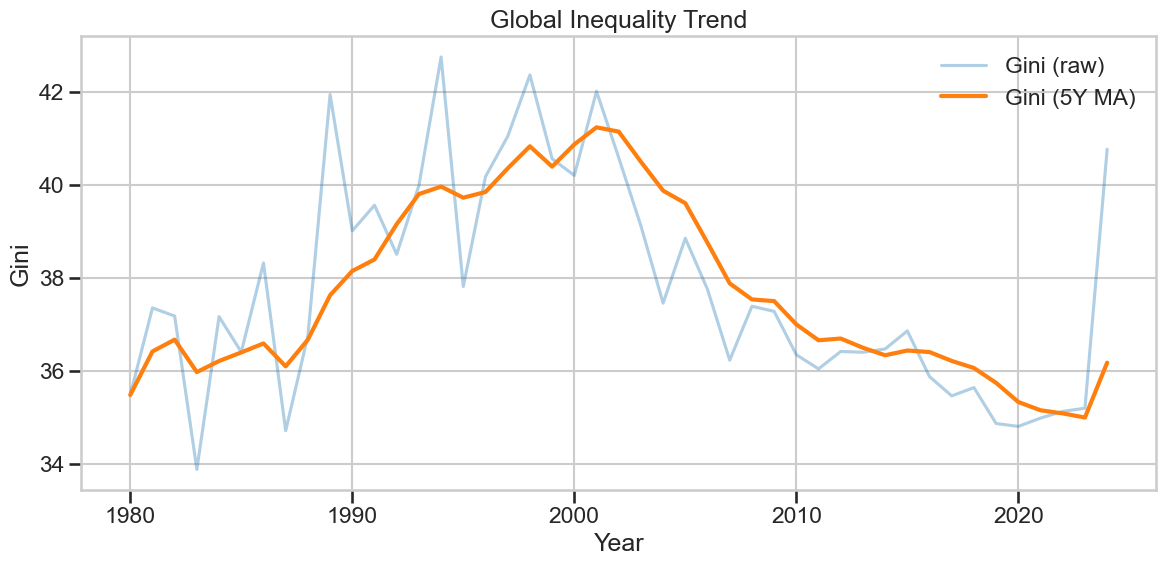

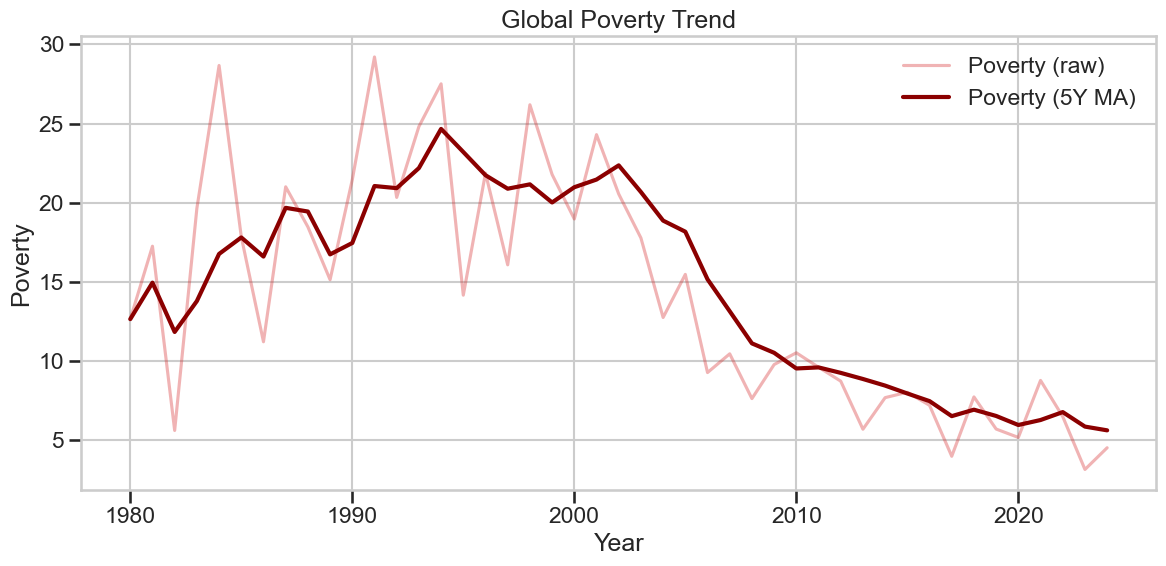

In [ ]:
print("="*70)
print("STEP 9: PROFESSIONAL VISUALIZATION")
print("="*70)

# 9.1 Time trends with rolling average
global_plot_df = df.groupby(year_col).agg(
    gini_mean=(gini_col, "mean"),
    poverty_mean=(poverty_col, "mean") if poverty_col else (gini_col, "size")
).reset_index()

global_plot_df["gini_ma5"] = global_plot_df["gini_mean"].rolling(5, min_periods=1).mean()
if poverty_col:
    global_plot_df["poverty_ma5"] = global_plot_df["poverty_mean"].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(global_plot_df[year_col], global_plot_df["gini_mean"], alpha=0.35, label="Gini (raw)")
ax.plot(global_plot_df[year_col], global_plot_df["gini_ma5"], linewidth=3, label="Gini (5Y MA)")
ax.set_title("Global Inequality Trend")
ax.set_xlabel("Year")
ax.set_ylabel("Gini")
ax.legend()
plt.tight_layout()
plt.show()

if poverty_col:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(global_plot_df[year_col], global_plot_df["poverty_mean"], alpha=0.35, label="Poverty (raw)", color="tab:red")
    ax.plot(global_plot_df[year_col], global_plot_df["poverty_ma5"], linewidth=3, label="Poverty (5Y MA)", color="darkred")
    ax.set_title("Global Poverty Trend")
    ax.set_xlabel("Year")
    ax.set_ylabel("Poverty")
    ax.legend()
    plt.tight_layout()
    plt.show()

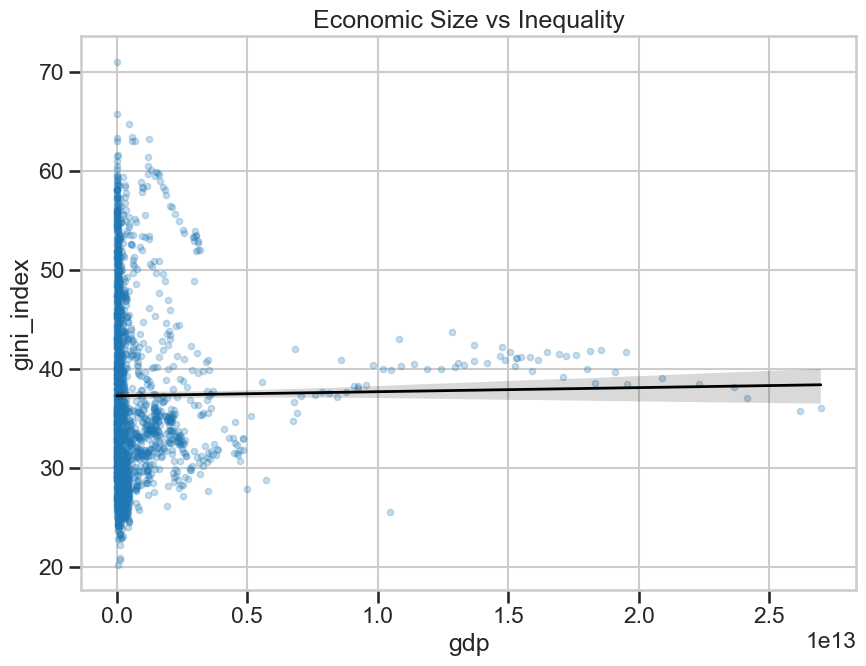

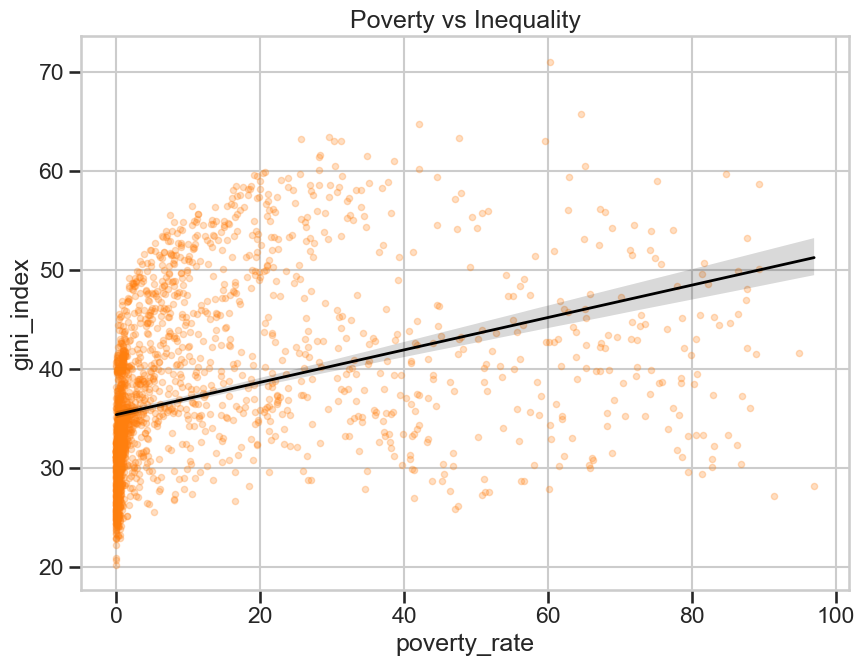

In [ ]:
# 9.2 Scatter + regression lines (already shown above, repeated with polish)
if gdp_col:
    plt.figure(figsize=(9, 7))
    sns.regplot(data=df, x=gdp_col, y=gini_col, scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"color": "black", "lw": 2})
    plt.title("Economic Size vs Inequality")
    plt.xlabel(gdp_col)
    plt.ylabel(gini_col)
    plt.tight_layout()
    plt.show()

if poverty_col:
    plt.figure(figsize=(9, 7))
    sns.regplot(data=df, x=poverty_col, y=gini_col, scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"color": "black", "lw": 2}, color="tab:orange")
    plt.title("Poverty vs Inequality")
    plt.xlabel(poverty_col)
    plt.ylabel(gini_col)
    plt.tight_layout()
    plt.show()

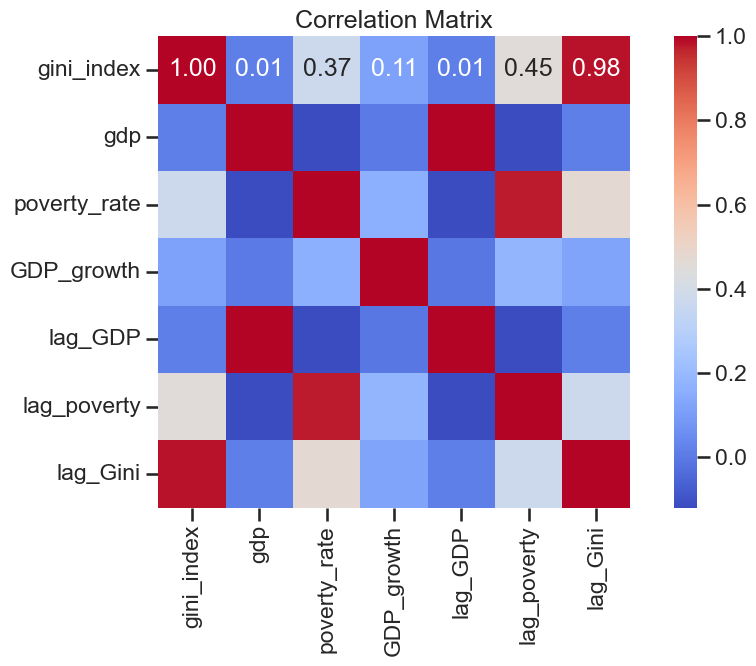

In [ ]:
# 9.3 Heatmap (Correlation Matrix)
corr_cols = [c for c in [gini_col, gdp_col, poverty_col, "GDP_growth", "lag_GDP", "lag_poverty", "lag_Gini"] if c and c in df.columns]
corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")
corr_mat = corr_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_mat, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()